:## Scenario 1 — Agentic AI for FSC Linear (Local info regime)

- Framework: Multi-agent
- Decision making: **Gemini** (per-tier LLM calls), **strict JSON schema enforced**.
- Agents pick **discrete policy knobs** only: `alpha`, `service_level`, `expedite`.
- All inventory/forecast math remains **deterministic in code**.
- Linear forward chain.


In [1]:
# ===== G2 — Setup =====
!pip -q install jsonschema google-generativeai

import os, json
from getpass import getpass

# 1) Read API key
if "GEMINI_API_KEY" not in os.environ or not os.environ["GEMINI_API_KEY"]:
    os.environ["GEMINI_API_KEY"] = getpass("Enter GEMINI_API_KEY: ")

# 2) Bypass any local proxies that may force localhost routing
for var in ["HTTP_PROXY","HTTPS_PROXY","ALL_PROXY","NO_PROXY","http_proxy","https_proxy","all_proxy","no_proxy"]:
    if var in os.environ:
        os.environ.pop(var, None)
# (Optional belt-and-suspenders)
os.environ["NO_PROXY"] = "*"

# 3) Configure client with explicit endpoint
import google.generativeai as genai
genai.configure(
    api_key=os.environ["GEMINI_API_KEY"],
    client_options={"api_endpoint": "https://generativelanguage.googleapis.com"}
)

# 4) Imports
import numpy as np
from dataclasses import dataclass
from typing import Dict, Any, List
from jsonschema import validate, ValidationError

# 5) Test
try:
    mdl = genai.GenerativeModel("gemini-1.5-flash")
    resp = mdl.generate_content("Return the single word: OK", request_options={"timeout": 6})
    print("Smoke test:", (resp.text or "").strip())
except Exception as e:
    print(" Test:", repr(e))

print("Setup complete.")


Enter GEMINI_API_KEY: ··········
Smoke test: OK
Setup complete.


In [2]:
# ===== R1. Roles, profiles, project, disruption, InfoBank =====
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional
import numpy as np

rng = np.random.default_rng(42)
horizonWeeks = 52

# Project demand (units per span) for Steel
customerDemand = np.array([
    0, 4, 0, 0, 1, 3, 1, 1, 7, 1,
    1, 4, 9, 3, 5, 1, 2, 12, 1, 0,
    6, 1, 1, 1, 1, 1, 2, 1, 4, 2,
    7, 1, 0, 0, 1, 4, 5, 0, 2, 0,
    0, 1, 1, 1, 1, 0, 1, 0,
    0, 0, 0, 0
])

# ---- Supply chain structure ----
ROLES = ["Sub", "PO", "3PL", "Dist", "Sup"]
FLOW = {"Sup": "Dist", "Dist": "3PL", "3PL": "PO", "PO": "Sub"}

NEIGHBORS = {
   "Sub": ["PO"],
   "PO": ["Sub", "3PL"],
   "3PL": ["PO", "Dist"],
   "Dist": ["3PL", "Sup"],
   "Sup": ["Dist"]
}

@dataclass
class Profile:
   name: str
   policy_version: int = 0
   share_keys: List[str] = field(default_factory=list)

profiles: Dict[str, Profile] = {
   "Sub":  Profile("Sub", share_keys=["backlog"]),
   "PO":   Profile("PO", share_keys=["backlog", "pipeline"]),
   "3PL":  Profile("3PL", share_keys=["pipeline"]),
   "Dist": Profile("Dist", share_keys=["on_hand", "backlog"]),
   "Sup":  Profile("Sup", share_keys=["on_hand", "pipeline"]),
}

# Minimal project info
project = {"id": "P1", "material": "Rebar#5"}

disruption = {
   "week": 30,
   "delta_leadtime": 2,
   "duration_weeks": 8,
}

# Noise parameter (not used, set 0)
leadtime_noise = 0

def degrade_obs(x: float, rel_std: float, rng) -> float:
   return float(max(0.0, x * (1.0 + rng.normal(0.0, rel_std))))

class InfoBank:
   def __init__(self, profiles: Dict[str, Profile], rng, info_regime: str = "local"):
       if info_regime not in ["local", "global"]:
           raise ValueError("info_regime must be 'local' or 'global'")
       self.profiles = profiles
       self.rng = rng
       self.info_regime = info_regime
       self.local: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

       # Shared data structure depends on regime
       if info_regime == "local":
           self.shared: Dict[str, Dict[str, Dict[str, Any]]] = {
               role: {neighbor: {} for neighbor in NEIGHBORS.get(role, [])}
               for role in ROLES
           }
       else:
           self.shared: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

       self.true_lead: Dict[str, int] = {
           "Sup->Dist": 3,
           "Dist->3PL": 1,
           "3PL->PO": 1,
           "PO->Sub": 0
       }
       self.time = 0

   def apply_disruption(self, t: int):
       if t == disruption["week"]:
           self.true_lead["Sup->Dist"] += disruption["delta_leadtime"]
       if t == disruption["week"] + disruption["duration_weeks"]:
           self.true_lead["Sup->Dist"] -= disruption["delta_leadtime"]

   def update_share_policy(self, role: str, add_keys: Optional[List[str]] = None, drop_keys: Optional[List[str]] = None):
       p = self.profiles[role]
       if add_keys:
           for k in add_keys:
               if k not in p.share_keys and k in ["on_hand", "backlog", "pipeline"]:
                   p.share_keys.append(k)
       if drop_keys:
           p.share_keys = [k for k in p.share_keys if k not in drop_keys]
       p.policy_version += 1

   def publish(self, role: str):
       policy_keys = set(self.profiles[role].share_keys)
       shared_data = {k: self.local[role].get(k) for k in policy_keys if k in self.local[role]}

       if self.info_regime == "local":
           neighbors = NEIGHBORS.get(role, [])
           for neighbor in neighbors:
               if neighbor in ROLES:
                   if neighbor not in self.shared:
                       self.shared[neighbor] = {}
                   self.shared[neighbor][role] = shared_data.copy()
       else:
           self.shared[role] = shared_data.copy()

   def context_view_for(self, role: str) -> Dict[str, Any]:
       view = {
           "role": role,
           "t": self.time,
           "project_id": project["id"],
           "material": project["material"]
       }
       view[f"{role}_self"] = {k: self.local[role].get(k) for k in self.local[role].keys()}

       if self.info_regime == "local":
           visible_roles = NEIGHBORS.get(role, [])
           for neighbor_role in visible_roles:
               neighbor_shared_data = self.shared.get(role, {}).get(neighbor_role, {})
               view[f"{neighbor_role}_shared"] = neighbor_shared_data
       else:
           visible_roles = [r for r in ROLES if r != role]
           for r in visible_roles:
               view[f"{r}_shared"] = self.shared.get(r, {}).copy()

       view["my_profile"] = {"policy_version": self.profiles[role].policy_version}
       view["info_regime_context"] = {
           "regime": self.info_regime,
           "visible_roles": visible_roles,
           "total_network_size": len(ROLES)
       }
       return view

   def _get_shared_insights(self, role: str) -> Dict[str, float]:
       """Aggregated insights from shared information"""
       downstream_backlog = 0.0
       upstream_inventory = 0.0
       visible_partners = []

       chain_order = {"Sup": 0, "Dist": 1, "3PL": 2, "PO": 3, "Sub": 4}
       my_position = chain_order.get(role, 2)

       if self.info_regime == "local":
           neighbors = NEIGHBORS.get(role, [])
           for neighbor_role in neighbors:
               shared_data = self.shared.get(role, {}).get(neighbor_role, {})
               if shared_data:
                   visible_partners.append(neighbor_role)
                   partner_position = chain_order.get(neighbor_role, 2)
                   if partner_position > my_position and "backlog" in shared_data:
                       downstream_backlog += float(shared_data["backlog"])
                   if partner_position < my_position and "on_hand" in shared_data:
                       upstream_inventory += float(shared_data["on_hand"])
       else:
           visible_roles = [r for r in ROLES if r != role]
           for visible_role in visible_roles:
               shared_data = self.shared.get(visible_role, {})
               if shared_data:
                   visible_partners.append(visible_role)
                   partner_position = chain_order.get(visible_role, 2)
                   if partner_position > my_position and "backlog" in shared_data:
                       downstream_backlog += float(shared_data["backlog"])
                   if partner_position < my_position and "on_hand" in shared_data:
                       upstream_inventory += float(shared_data["on_hand"])

       return {
           "downstream_backlog": downstream_backlog,
           "upstream_inventory": upstream_inventory,
           "visible_partners": len(visible_partners)
       }

   def math_signals_for(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
       t = self.time

       if role == "Sub":
           downstream_orders = np.asarray(customerDemand, dtype=float)
       elif role == "PO":
           if "orders_out" in hist and "Sub" in hist["orders_out"]:
               downstream_orders = np.asarray(hist["orders_out"]["Sub"], dtype=float)
           else:
               downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))  # No info = no orders
       elif role == "3PL":
           if "orders_out" in hist and "PO" in hist["orders_out"]:
               po_orders = np.asarray(hist["orders_out"]["PO"], dtype=float)
               recent_orders = po_orders[max(0, t-8):t+1]
               recent_total = recent_orders.sum()
               downstream_orders = po_orders if recent_total > 0.8 else np.zeros_like(np.asarray(customerDemand, dtype=float))
           else:
               downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))  # No info = no orders
       elif role == "Dist":
           if "orders_out" in hist and "3PL" in hist["orders_out"]:
               tpl_orders = np.asarray(hist["orders_out"]["3PL"], dtype=float)
               recent_orders = tpl_orders[max(0, t-8):t+1]
               recent_total = recent_orders.sum()
               downstream_orders = tpl_orders if recent_total > 1.0 else np.zeros_like(np.asarray(customerDemand, dtype=float))
           else:
               downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))  # No info = no orders
       elif role == "Sup":
           if "orders_out" in hist and "Dist" in hist["orders_out"]:
               dist_orders = np.asarray(hist["orders_out"]["Dist"], dtype=float)
               recent_orders = dist_orders[max(0, t-8):t+1]
               recent_total = recent_orders.sum()
               downstream_orders = dist_orders if recent_total > 0.5 else np.zeros_like(np.asarray(customerDemand, dtype=float))
           else:
               downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))  # No info = no orders
       else:
           downstream_orders = np.zeros_like(np.asarray(customerDemand, dtype=float))

       # Demand stats
       win = downstream_orders[max(0, t-window):t+1]
       dmean = float(win.mean()) if win.size else 0.0
       dstd = float(win.std(ddof=0)) if win.size else 0.0

       # Shared insights adjust demand mean
       shared_insights = self._get_shared_insights(role)
       if shared_insights["downstream_backlog"] > 0 and dmean > 0:
           backlog_factor = 1.0 + min(0.2, shared_insights["downstream_backlog"] / dmean)
           dmean *= backlog_factor

       # Inventory position (self)
       inv = float(self.local[role].get("on_hand", 0.0))
       bkl = float(self.local[role].get("backlog", 0.0))
       pip = float(self.local[role].get("pipeline", 0.0))
       invpos_obs = inv + pip - bkl

       # Lead time observation
       link = {
           "PO": "3PL->PO",
           "3PL": "Dist->3PL",
           "Dist": "Sup->Dist",
           "Sub": "PO->Sub"
       }.get(role, None)
       if link is None:
           L_obs = 0.0
       else:
           L_true = self.true_lead[link]
           L_obs = degrade_obs(L_true, leadtime_noise, self.rng)

       return {
           "t": t,
           "downstream_mean_obs": dmean,
           "downstream_std_obs": dstd,
           "inventory_position_obs": invpos_obs,
           "lead_time_obs": float(L_obs),
           "shared_visibility": shared_insights["visible_partners"],
           "info_regime": self.info_regime,
       }

   def view_for_agent(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
       return {
           "context_view": self.context_view_for(role),
           "math_signals": self.math_signals_for(role, hist, window),
       }


In [3]:
# ===== R2 — LLM Agent Decision Making =====
import json
from typing import Dict, Any, List
import math
import google.generativeai as genai

# ----------------------------
# Valid information sharing keys
# ----------------------------
allowed_share_keys = {"on_hand", "backlog", "pipeline"}

# ----------------------------
# JSON schema for LLM output
# ----------------------------
coeff_schema = {
    "type": "object",
    "properties": {
        "alpha": {"type": "number"},
        "service_level": {"type": "number"},
        "lot_multiplier": {"type": "number"},
        "expedite": {"type": "boolean"},
        "share_add": {"type": "array", "items": {"type": "string"}},
        "share_drop": {"type": "array", "items": {"type": "string"}},
    },
    "required": ["alpha", "service_level", "lot_multiplier", "expedite"],
}

coeff_generation_config = genai.GenerationConfig(
    temperature=0.4,
    response_mime_type="application/json",
    response_schema=coeff_schema,
)

gemini_coeff = genai.GenerativeModel(
    model_name="gemini-1.5-flash",
    generation_config=coeff_generation_config,
    system_instruction=(
        "You are a role-bound decision maker in a multi-agent construction supply chain simulation. "
        "Optimize your local objective given the stated context and uncertainty. "
        "Assume only the information provided. "
        "Output must be valid JSON matching the schema in the user prompt. No prose."
    ),
)

REQUIRED_KEYS = {"alpha", "service_level", "lot_multiplier", "expedite", "share_add", "share_drop"}

# ----------------------------
# Validation
# ----------------------------
def validate_coeffs(obj: Dict[str, Any]) -> Dict[str, Any]:
    # Fill optional keys if missing
    obj = {**{"share_add": [], "share_drop": []}, **obj}

    keys = set(obj.keys())
    missing = {"alpha", "service_level", "lot_multiplier", "expedite"} - keys
    extras = keys - REQUIRED_KEYS
    if missing:
        raise ValueError(f"Missing required keys: {sorted(missing)}")
    if extras:
        raise ValueError(f"Extra keys not allowed: {sorted(extras)}")

    # Type checks
    if not isinstance(obj["alpha"], (int, float)) or not (0.05 <= obj["alpha"] <= 0.50):
        raise ValueError(f"alpha {obj['alpha']} must be a number in [0.05, 0.50]")
    if not isinstance(obj["service_level"], (int, float)) or not (0.80 <= obj["service_level"] <= 0.95):
        raise ValueError(f"service_level {obj['service_level']} must be a number in [0.80, 0.95]")
    if not isinstance(obj["lot_multiplier"], (int, float)) or not (0.50 <= obj["lot_multiplier"] <= 2.00):
        raise ValueError(f"lot_multiplier {obj['lot_multiplier']} must be a number in [0.50, 2.00]")
    if not isinstance(obj["expedite"], bool):
        raise ValueError(f"expedite {obj['expedite']} must be true or false")

    # Validate sharing keys
    for k in ("share_add", "share_drop"):
        if not isinstance(obj[k], list):
            raise ValueError(f"{k} must be a list")
        bad = [x for x in obj[k] if x not in allowed_share_keys]
        if bad:
            raise ValueError(f"{k} contains invalid keys: {bad}")

    # Rounding 2 points
    obj["alpha"] = round(float(obj["alpha"]), 2)
    obj["service_level"] = round(float(obj["service_level"]), 2)
    obj["lot_multiplier"] = round(float(obj["lot_multiplier"]), 2)
    return obj

# ----------------------------
# Role strategies (made up of statements accurately representing essence of the first study)
# https://arxiv.org/abs/2402.07927
# https://arxiv.org/abs/2502.10708
# ----------------------------
ROLE_STRATEGIES = {
    "Sub": {
        "position": "End consumer: directly faces project demand",
        "key_pressure": "Crew idle time is highly costly; stockouts cause immediate work stoppage",
        "inventory_reality": "Very limited on-site storage; frequent deliveries are necessary",
        "optimal_strategy": "Maintain high responsiveness to demand changes while avoiding overstock; prefer smaller, more frequent orders",
        "decision_drivers": "React quickly to schedule changes and minimize storage-related risk"
    },
    "PO": {
        "position": "Specialized procurement function: natural broker",
        "key_pressure": "Bridge between design specs and supplier capabilities despite limited authority",
        "inventory_reality": "Minimal direct inventory control; focused on specification and sourcing",
        "optimal_strategy": "Leverage brokerage position to coordinate early supplier engagement while working within limited organizational mandate",
        "decision_drivers": "Navigate structural holes between production, oversight, and execution while building case for expanded coordination role"
    },
    "3PL": {
        "position": "Material consolidation yard: aggregates shipments and manages delivery timing",
        "key_pressure": "Consolidation efficiency versus delivery responsiveness; balancing batch economies with urgency",
        "inventory_reality": "Short-term staging for consolidation; costs rise with holding time but efficiency improves with larger batches",
        "optimal_strategy": "Balance quick response to urgent orders against waiting to consolidate efficient full loads; smooth irregular upstream deliveries into steady downstream flow",
        "decision_drivers": "Trade off immediate delivery against consolidation savings; manage variability between lumpy supplier deliveries and steady customer needs"
    },
    "Dist": {
        "position": "Regional warehouse: serves multiple customers and buffers variability",
        "key_pressure": "Significant holding costs versus reputational risk from service failures",
        "inventory_reality": "Large capacity but costly to maintain at high occupancy",
        "optimal_strategy": "Smooth variability, uphold high service reliability, and consolidate orders for efficiency",
        "decision_drivers": "Optimize storage efficiency while safeguarding customer retention"
    },
    "Sup": {
        "position": "Production facility: furthest upstream from end demand",
        "key_pressure": "High setup and holding costs; frequent changeovers reduce efficiency",
        "inventory_reality": "Capacity and scheduling constraints; efficiency improves with longer runs",
        "optimal_strategy": "Stabilize production with longer, consistent runs while keeping enough inventory to ensure downstream reliability",
        "decision_drivers": "Reduce changeovers, maintain production efficiency, and provide dependable supply"
    }
}


# ----------------------------
# Decision glossary and prompt creation
# ----------------------------
decision_glossary = f"""
Critical: All values must be in these exact ranges

Decision knobs (numeric):
- responsiveness (alpha) in [0.05, 0.50]
  Meaning: weight on recent demand signals vs. historical smoothing.
  Higher= reacts faster to changes; Lower= smooths noise and favors stability.
- service_level in [0.80, 0.95]
  Meaning: reliability target for avoiding stockout before replenishment.
  Higher= fewer stockouts but more inventory; Lower= leaner inventory with higher risk.
- lot_multiplier in [0.50, 2.00]
  Meaning: order/batch size relative to a nominal order.
  Higher= larger, less frequent orders (efficiency, less flexibility); Lower= smaller, more frequent orders (flexibility, more ordering overhead).
- expedite in {{true,false}}
  Meaning: pay a premium to shorten delay when stockout risk is material.
- share_add / share_drop are subsets of {sorted(list(allowed_share_keys))}
  Meaning: information you will start/stop sharing this week to improve coordination.

Constraints:
- Provide numeric values only (two decimals max) for alpha, service_level, and lot_multiplier.
- Stay within the ranges above; if you would go outside, choose the nearest bound.
- Base choices on this week's signals (volatility, cover, backlog, lead-time), not on assumptions.
"""

def _create_role_specific_prompt(role: str, view: Dict[str, Any]) -> str:
    strategy = ROLE_STRATEGIES[role]
    week = view.get("week", "?")
    situation_analysis = view.get("situation_analysis", "")
    disruption_note = view.get("disruption_note", "")

    prompt = f"""You are operating as: {strategy['position']} (week {week}).

{situation_analysis}
Role context:
- Key pressure: {strategy['key_pressure']}
- Inventory reality: {strategy['inventory_reality']}
- Recommended stance (qualitative): {strategy['optimal_strategy']}
- Decision drivers: {strategy['decision_drivers']}

{disruption_note or ""}

{decision_glossary}

OUTPUT (valid JSON only; no prose):
{{
  "alpha": <number>,
  "service_level": <number>,
  "lot_multiplier": <number>,
  "expedite": <true|false>,
  "share_add": <list of strings from allowed keys>,
  "share_drop": <list of strings from allowed keys>
}}"""
    return prompt

# ----------------------------
# LLM call with retries
# ----------------------------
def llm_choose_coeffs(role: str, view: Dict[str, Any]) -> Dict[str, Any]:
    """Call LLM with role-specific prompts, validate and return numeric coefficients."""
    prompt = _create_role_specific_prompt(role, view)

    last_err = None
    for attempt in range(3):
        if attempt == 0:
            resp = gemini_coeff.generate_content([prompt])
        else:
            repair_msg = (
                "Your previous output was invalid. Re-output VALID JSON ONLY that meets the schema and ranges. "
                "Do not add any text outside JSON."
            )
            resp = gemini_coeff.generate_content([repair_msg, prompt])

        text = getattr(resp, "text", "") or ""
        try:
            obj = json.loads(text)
            return validate_coeffs(obj)
        except Exception as e:
            last_err = e
            continue

    # If all retries fail, raise the last parsing error
    raise ValueError(f"LLM output could not be validated after retries: {last_err}")


In [4]:
# ===== R3 — Supply Chain Formulas =====
import numpy as np
from scipy import stats

def zFromServiceLevel(p: float) -> float:
    """
    Convert service level to z-score using inverse normal distribution.
    """
    if not (0.5 <= p <= 0.999):
        raise ValueError(f"Service level {p} must be between 0.5 and 0.999")
    return float(stats.norm.ppf(p))

def update_forecast(prev_forecast: float, signal_mean_obs: float, alpha: float) -> float:
    """Exponential smoothing driven by observed mean demand."""
    return alpha * signal_mean_obs + (1.0 - alpha) * prev_forecast

def base_stock_target(mu_hat: float, dstd_obs: float, L_obs: float, z: float) -> float:
    """
    Uses (L_obs + 1) convention (cycle + pipeline).
    """
    mean_LT = mu_hat * (L_obs + 1.0)
    std_LT  = dstd_obs * np.sqrt(max(0.0, L_obs + 1.0))
    return mean_LT + z * std_LT

def compute_order_qty(invpos_obs: float, target: float, lot_multiplier: float) -> float:
    """
    Gap-based ordering with a lot-size multiplier (agent-chosen).
    """
    gap = max(0.0, target - invpos_obs)
    return max(0.0, lot_multiplier * gap)

In [5]:
# ===== R4 — Simulation Runner =====
from typing import Dict, Any
import numpy as np

def apply_realistic_constraints(role: str, raw_order_qty: float, ms: dict, t: int) -> float:
    """
    Apply constraints to prevent unrealistic ordering behavior
    """
    weekly_demand = max(1.0, ms["downstream_mean_obs"])
    current_inventory = ms["inventory_position_obs"]

    # Maximum inventory constraints by role
    if role == "Dist":
        max_inventory = weekly_demand * 3.0
    elif role == "Sup":
        max_inventory = weekly_demand * 2.5
    elif role == "3PL":
        max_inventory = weekly_demand * 2.0
    else:
        max_inventory = weekly_demand * 4.0

    # Maximum single order
    max_single_order = weekly_demand * 1.5

    # If inventory is already too high, force zero ordering
    if current_inventory > max_inventory:
        constrained_qty = 0.0
    else:
        # Limit order size to not exceed max inventory
        max_order_by_capacity = max(0.0, max_inventory - current_inventory)
        constrained_qty = min(raw_order_qty, max_single_order, max_order_by_capacity)

        # Force minimum ordering if inventory is getting low
        min_inventory_threshold = weekly_demand
        if current_inventory < min_inventory_threshold and constrained_qty < weekly_demand * 0.5:
            forced_min = weekly_demand * 0.5
            constrained_qty = max(constrained_qty, forced_min)

    return constrained_qty

def run_construction_scenario(
    T: int,
    info_bank: InfoBank,
    rng,
    window: int = 8,
    sup_production_lead: int = 1,
):
    # Time-series histories
    hist = {
        "on_hand":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "backlog":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "pipeline":      {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_in":     {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_out":    {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_in":  {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_out": {r: np.zeros(T, dtype=float) for r in ROLES},
    }

    # Arrival schedules
    arrivals = {r: np.zeros(T + 16, dtype=float) for r in ROLES}

    # Low starting inventory to force ordering
    for r in ROLES:
        if r == "Sub":
            info_bank.local[r]["on_hand"] = 5.0
        elif r == "PO":
            info_bank.local[r]["on_hand"] = 8.0
        elif r == "3PL":
            info_bank.local[r]["on_hand"] = 4.0
        elif r == "Dist":
            info_bank.local[r]["on_hand"] = 3.0
        elif r == "Sup":
            info_bank.local[r]["on_hand"] = 6.0
        else:
            info_bank.local[r]["on_hand"] = 0.0

        info_bank.local[r]["backlog"] = 0.0
        info_bank.local[r]["pipeline"] = 0.0

    # Initialize history from InfoBank
    for r in ROLES:
        hist["on_hand"][r][0]  = float(info_bank.local[r]["on_hand"])
        hist["backlog"][r][0]  = float(info_bank.local[r]["backlog"])
        hist["pipeline"][r][0] = float(info_bank.local[r]["pipeline"])

    # Per-role forecasts
    forecast = {r: np.zeros(T, dtype=float) for r in ROLES}
    init_mean = customerDemand[:max(1, min(10, T))].mean()
    for r in ROLES:
        forecast[r][0] = init_mean

    # Coefficient logs
    coeff_logs: Dict[str, list[Dict[str, Any]]] = {r: [] for r in ROLES}

    # Pipeline trackers
    pipeline_now = {r: hist["pipeline"][r][0] for r in ROLES}

    for t in range(T):
        # Advance time and apply disruptions
        info_bank.time = t
        info_bank.apply_disruption(t)

        # Process arrivals
        for r in ROLES:
            a = float(arrivals[r][t])
            if a > 0:
                hist["shipments_in"][r][t] += a
                hist["on_hand"][r][t] += a
                pipeline_now[r] = max(0.0, pipeline_now[r] - a)

        # Calculate incoming orders
        for r in ROLES:
            if r == "Sub":
                demand_t = float(customerDemand[t])
            else:
                customer_role = None
                if r == "PO":
                    customer_role = "Sub"
                elif r == "3PL":
                    customer_role = "PO"
                elif r == "Dist":
                    customer_role = "3PL"
                elif r == "Sup":
                    customer_role = "Dist"

                demand_t = float(hist["orders_out"][customer_role][t-1]) if (customer_role and t > 0) else 0.0

            hist["orders_in"][r][t] = demand_t

        # Process shipments and update backlog
        for r in ROLES:
            need = hist["backlog"][r][t] + hist["orders_in"][r][t]
            ship = min(hist["on_hand"][r][t], need)
            hist["shipments_out"][r][t] = ship
            hist["on_hand"][r][t] -= ship
            hist["backlog"][r][t] = need - ship

        # Sync InfoBank with current state
        for r in ROLES:
            info_bank.local[r]["on_hand"]  = float(hist["on_hand"][r][t])
            info_bank.local[r]["backlog"]  = float(hist["backlog"][r][t])
            info_bank.local[r]["pipeline"] = float(pipeline_now[r])

        # LLM decision making and ordering
        for r in ROLES:
            view = info_bank.view_for_agent(r, hist, window=window)
            coeffs = llm_choose_coeffs(r, view)
            coeff_logs[r].append({"t": t, **coeffs})

            # Apply sharing policy changes then publish
            if coeffs.get("share_add") or coeffs.get("share_drop"):
                info_bank.update_share_policy(r, add_keys=coeffs.get("share_add"), drop_keys=coeffs.get("share_drop"))
            info_bank.publish(r)

            # Calculate order quantities
            if r == "Sub":
                q = max(0.0, customerDemand[t])
            else:
                ms = view["math_signals"]
                alpha = coeffs["alpha"]
                service_level = coeffs["service_level"]
                lot_mult = coeffs["lot_multiplier"]

                # Update forecast
                prev_f = forecast[r][t-1] if t > 0 else forecast[r][0]
                mu_hat = update_forecast(prev_f, ms["downstream_mean_obs"], alpha)
                forecast[r][t] = mu_hat

                # Cap service level and lot multiplier to prevent unrealistic behavior
                capped_service_level = min(service_level, 0.88)
                capped_lot_mult = min(lot_mult, 1.25)

                # Calculate target and order quantity
                z = zFromServiceLevel(capped_service_level)
                target = base_stock_target(mu_hat, ms["downstream_std_obs"], ms["lead_time_obs"], z)
                raw_q = compute_order_qty(ms["inventory_position_obs"], target, capped_lot_mult)

                # Apply constraints
                q = apply_realistic_constraints(r, raw_q, ms, t)

            # Expedite logic
            if bool(coeffs["expedite"]) and hist["backlog"][r][t] > 0:
                exp_now = min(q * 0.25, hist["backlog"][r][t])
                hist["shipments_in"][r][t] += exp_now
                hist["on_hand"][r][t] += exp_now

            hist["orders_out"][r][t] = q

            # Schedule production and shipments
            if r == "Sup":
                prod_lead = int(max(0, sup_production_lead))
                t_arr_sup = t + prod_lead
                if t_arr_sup < len(arrivals["Sup"]) and q > 0:
                    arrivals["Sup"][t_arr_sup] += q
                    pipeline_now["Sup"] += q

            # Schedule shipments to downstream
            down = FLOW.get(r)
            if down is not None:
                link = f"{r}->{down}"
                L_ship = int(max(0, info_bank.true_lead.get(link, 0)))
                t_arr_down = t + L_ship
                ship_qty = float(hist["shipments_out"][r][t])
                if ship_qty > 0 and t_arr_down < len(arrivals[down]):
                    arrivals[down][t_arr_down] += ship_qty
                    pipeline_now[down] += ship_qty

        # Carry forward state to next period
        if t < T - 1:
            for r in ROLES:
                hist["on_hand"][r][t+1]  = hist["on_hand"][r][t]
                hist["backlog"][r][t+1]  = hist["backlog"][r][t]
                hist["pipeline"][r][t+1] = hist["pipeline"][r][t]

    return hist, forecast, coeff_logs, info_bank

# Initialize InfoBank and run simulation
info_bank = InfoBank(profiles=profiles, rng=rng, info_regime="local")

hist_roles, forecast_roles, coeff_logs, info_bank = run_construction_scenario(
    T=horizonWeeks,
    info_bank=info_bank,
    rng=rng,
    window=8,
    sup_production_lead=1,
)
print("Simulation complete.")


Simulation complete.


ORDER ACTIVITY (category totals):
Sub : Total=  101.0, Active_weeks=37/52, Max=   12.0
PO  : Total=  104.2, Active_weeks=21/52, Max=    7.8
3PL : Total=  149.8, Active_weeks=21/52, Max=   12.4
Dist: Total=  202.3, Active_weeks=19/52, Max=   20.0
Sup : Total=  215.3, Active_weeks=19/52, Max=   20.4

WEEKLY ORDER PATTERNS (category totals):
 week  Sub_order  PO_order  3PL_order  Dist_order  Sup_order
    0        0.0       0.0        0.0         0.0        0.0
   10        1.0       3.0        3.4         2.0        0.0
   20        6.0       7.8       12.3        15.9       17.3
   30        7.0       0.0        0.0         0.0        0.7
   40        0.0       0.0        0.0         0.0        0.0
   50        0.0       0.0        0.0         0.0        0.0

INVENTORY ANALYSIS (category totals):

3PL:
  Week 20: on_hand=0.0, backlog=43.5, pipeline=0.0
  Week 20: inv_pos=-43.5
  Avg inventory (weeks 10-51): 29.1

Dist:
  Week 20: on_hand=0.0, backlog=46.2, pipeline=0.0
  Week 20: inv_po

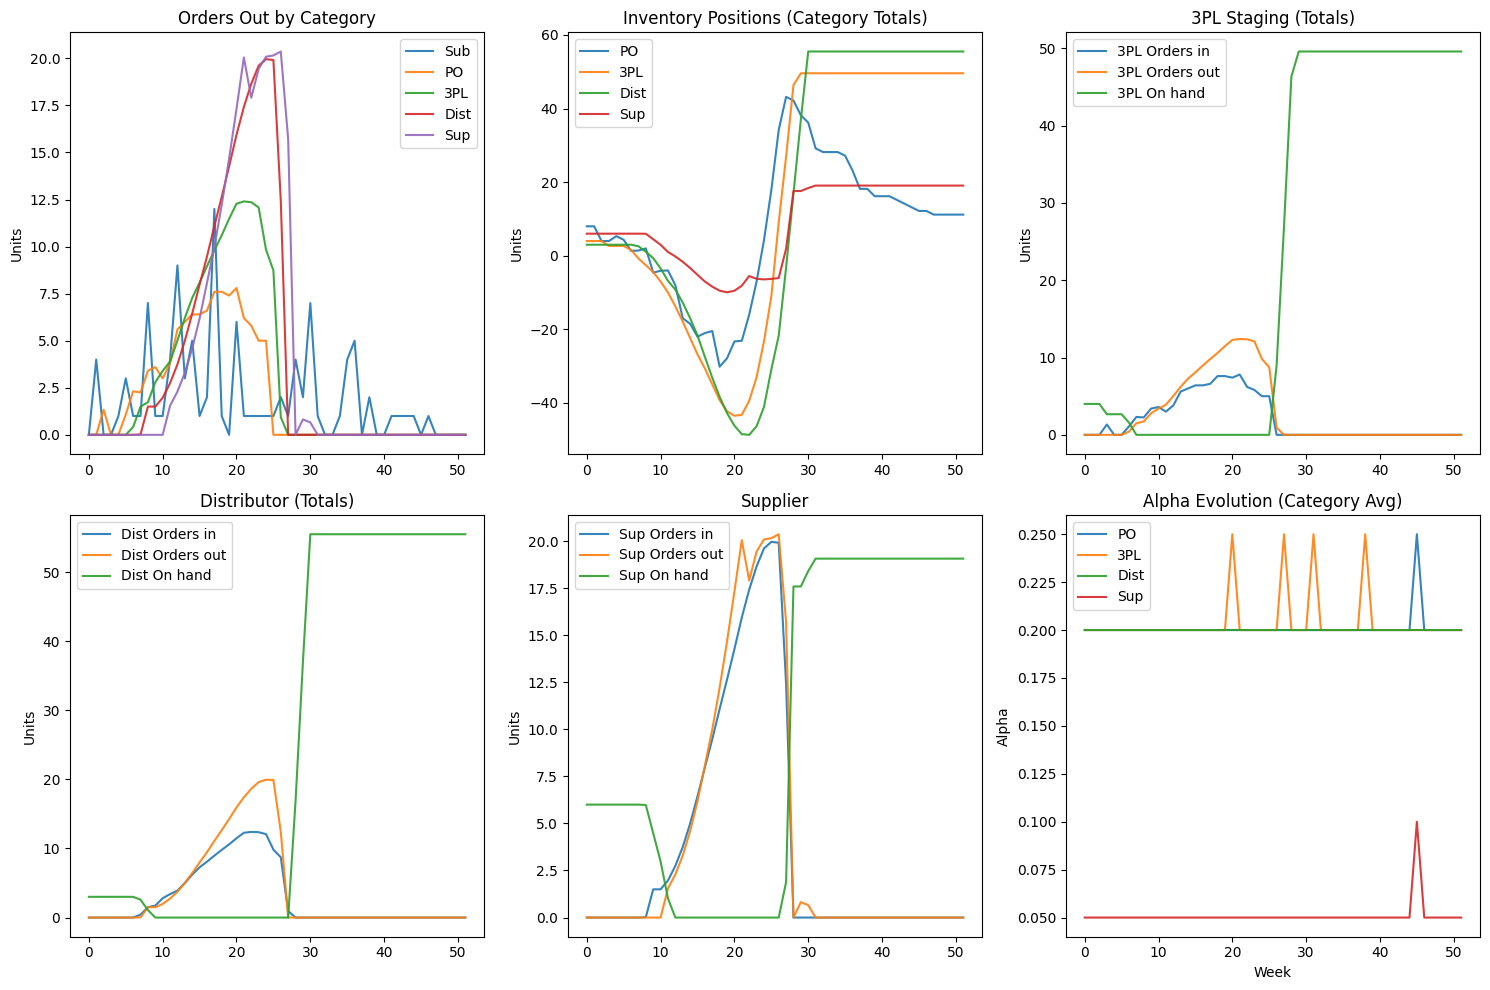

In [6]:
# ===== Post-Run Diagnostics =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _roles_by_prefix(prefixes):
    return [r for r in ROLES if any(r == p or r.startswith(p) for p in prefixes)]

SUBS      = _roles_by_prefix(["Sub"])
POS_      = _roles_by_prefix(["PO"])
THREEPLS  = _roles_by_prefix(["3PL"])
DISTS_    = _roles_by_prefix(["Dist"])
SUPS_     = _roles_by_prefix(["Sup"])

def _sum_series(role_list, series_dict):
    if not role_list:
        return None
    arrs = [np.asarray(series_dict[r], dtype=float) for r in role_list]
    return np.sum(arrs, axis=0)

def _avg_coeff(role_list, coeff_logs, key):
    vals = []
    for r in role_list:
        if r in coeff_logs and coeff_logs[r]:
            vals.extend([float(c[key]) for c in coeff_logs[r] if key in c])
    return (np.mean(vals) if vals else np.nan)

def _count_true(role_list, coeff_logs, key):
    cnt = 0
    for r in role_list:
        if r in coeff_logs and coeff_logs[r]:
            cnt += sum(bool(c.get(key, False)) for c in coeff_logs[r])
    return cnt

if 'hist_roles' in globals() and 'coeff_logs' in globals():
    T = len(next(iter(hist_roles["on_hand"].values())))
    weeks_to_check = [w for w in [0, 10, 20, 30, 40, 50] if w < T]

    # ---------- ORDER ACTIVITY (category totals) ----------
    print("ORDER ACTIVITY (category totals):")
    cat_map = {
        "Sub":  SUBS,
        "PO":   POS_,
        "3PL":  THREEPLS,
        "Dist": DISTS_,
        "Sup":  SUPS_,
    }
    for cat, roles in cat_map.items():
        series = _sum_series(roles, hist_roles["orders_out"])
        if series is None:
            continue
        total_orders = series.sum()
        non_zero_weeks = int((series > 0.1).sum())
        max_order = float(series.max())
        print(f"{cat:4s}: Total={total_orders:7.1f}, Active_weeks={non_zero_weeks:2d}/{T}, Max={max_order:7.1f}")

    # ---------- WEEKLY ORDER PATTERNS (category totals) ----------
    print("\nWEEKLY ORDER PATTERNS (category totals):")
    order_rows = []
    for t in weeks_to_check:
        row = {"week": t}
        for cat, roles in cat_map.items():
            s = _sum_series(roles, hist_roles["orders_out"])
            if s is not None:
                row[f"{cat}_order"] = float(s[t])
        order_rows.append(row)
    df_orders = pd.DataFrame(order_rows)
    with pd.option_context('display.float_format', lambda x: f"{x:7.1f}"):
        print(df_orders.to_string(index=False))

    # ---------- INVENTORY ANALYSIS (upstream categories) ----------
    print("\nINVENTORY ANALYSIS (category totals):")
    for cat, roles in [("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_)]:
        on_hand  = _sum_series(roles, hist_roles["on_hand"])
        backlog  = _sum_series(roles, hist_roles["backlog"])
        pipeline = _sum_series(roles, hist_roles["pipeline"])
        if on_hand is None:
            continue
        inv_pos = on_hand + pipeline - backlog
        wk = weeks_to_check[2] if len(weeks_to_check) >= 3 else weeks_to_check[-1]
        print(f"\n{cat}:")
        print(f"  Week {wk:2d}: on_hand={on_hand[wk]:.1f}, backlog={backlog[wk]:.1f}, pipeline={pipeline[wk]:.1f}")
        print(f"  Week {wk:2d}: inv_pos={inv_pos[wk]:.1f}")
        start = min(10, T-1)
        print(f"  Avg inventory (weeks {start}-{T-1}): {on_hand[start:].mean():.1f}")

    # ---------- COEFFICIENT ANALYSIS (averaged by category) ----------
    print("\nCOEFFICIENT ANALYSIS (category averages):")
    for cat, roles in cat_map.items():
        a = _avg_coeff(roles, coeff_logs, "alpha")
        s = _avg_coeff(roles, coeff_logs, "service_level")
        l = _avg_coeff(roles, coeff_logs, "lot_multiplier")
        e = _count_true(roles, coeff_logs, "expedite")
        if not np.isnan(a):
            print(f"{cat:4s}: alpha={a:.2f}, service={s:.2f}, lot={l:.2f}, expedites={e}")

    # ---------- SUPPLY CHAIN FLOW (category totals) ----------
    print("\nSUPPLY CHAIN FLOW (category totals):")
    flow_rows = []
    for t in [w for w in [10, 20, 30, 40] if w < T]:
        row = {"week": t}
        # Sub_out: orders placed by all subs (their demand)
        row["Sub_out"] = float(_sum_series(SUBS, hist_roles["orders_out"])[t]) if SUBS else 0.0
        # PO_in/out:
        row["PO_in"]  = float(_sum_series(POS_, hist_roles["orders_in"])[t])  if POS_ else 0.0
        row["PO_out"] = float(_sum_series(POS_, hist_roles["orders_out"])[t]) if POS_ else 0.0
        # 3PL in/out:
        row["3PL_in"]  = float(_sum_series(THREEPLS, hist_roles["orders_in"])[t])  if THREEPLS else 0.0
        row["3PL_out"] = float(_sum_series(THREEPLS, hist_roles["orders_out"])[t]) if THREEPLS else 0.0
        # Dist in/out:
        row["Dist_in"]  = float(_sum_series(DISTS_, hist_roles["orders_in"])[t])  if DISTS_ else 0.0
        row["Dist_out"] = float(_sum_series(DISTS_, hist_roles["orders_out"])[t]) if DISTS_ else 0.0
        # Sup_in:
        row["Sup_in"] = float(_sum_series(SUPS_, hist_roles["orders_in"])[t]) if SUPS_ else 0.0
        flow_rows.append(row)
    df_flow = pd.DataFrame(flow_rows)
    with pd.option_context('display.float_format', lambda x: f"{x:7.1f}"):
        print(df_flow.to_string(index=False))

    # ---------- PLOTS (category totals) ----------
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    ax = axes[0,0]
    for cat, roles in cat_map.items():
        s = _sum_series(roles, hist_roles["orders_out"])
        if s is not None:
            ax.plot(s, label=cat, alpha=0.9)
    ax.set_title("Orders Out by Category"); ax.legend(); ax.set_ylabel("Units")

    ax = axes[0,1]
    for cat, roles in [("PO", POS_), ("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_)]:
        oh = _sum_series(roles, hist_roles["on_hand"])
        bl = _sum_series(roles, hist_roles["backlog"])
        pl = _sum_series(roles, hist_roles["pipeline"])
        if oh is None:
            continue
        inv_pos = oh + pl - bl
        ax.plot(inv_pos, label=cat, alpha=0.9)
    ax.set_title("Inventory Positions (Category Totals)"); ax.legend(); ax.set_ylabel("Units")

    ax = axes[0,2]
    if THREEPLS:
        ax.plot(_sum_series(THREEPLS, hist_roles["orders_in"]),  label="3PL Orders in",  alpha=0.9)
        ax.plot(_sum_series(THREEPLS, hist_roles["orders_out"]), label="3PL Orders out", alpha=0.9)
        ax.plot(_sum_series(THREEPLS, hist_roles["on_hand"]),    label="3PL On hand",    alpha=0.9)
    ax.set_title("3PL Staging (Totals)"); ax.legend(); ax.set_ylabel("Units")

    ax = axes[1,0]
    if DISTS_:
        ax.plot(_sum_series(DISTS_, hist_roles["orders_in"]),  label="Dist Orders in",  alpha=0.9)
        ax.plot(_sum_series(DISTS_, hist_roles["orders_out"]), label="Dist Orders out", alpha=0.9)
        ax.plot(_sum_series(DISTS_, hist_roles["on_hand"]),    label="Dist On hand",    alpha=0.9)
    ax.set_title("Distributor (Totals)"); ax.legend(); ax.set_ylabel("Units")

    ax = axes[1,1]
    if SUPS_:
        ax.plot(_sum_series(SUPS_, hist_roles["orders_in"]),  label="Sup Orders in",  alpha=0.9)
        ax.plot(_sum_series(SUPS_, hist_roles["orders_out"]), label="Sup Orders out", alpha=0.9)
        ax.plot(_sum_series(SUPS_, hist_roles["on_hand"]),    label="Sup On hand",    alpha=0.9)
    ax.set_title("Supplier"); ax.legend(); ax.set_ylabel("Units")

    ax = axes[1,2]
    # Average alpha over time by category (only looks where coeffs exist)
    for cat, roles in [("PO", POS_), ("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_)]:
        alphas_per_role = []
        for r in roles:
            if r in coeff_logs and coeff_logs[r]:
                alphas_per_role.append([c["alpha"] for c in coeff_logs[r]])
        if not alphas_per_role:
            continue
        min_len = min(len(a) for a in alphas_per_role)
        if min_len == 0:
            continue
        arr = np.array([a[:min_len] for a in alphas_per_role], dtype=float)
        ax.plot(arr.mean(axis=0), label=cat, alpha=0.9)
    ax.set_title("Alpha Evolution (Category Avg)"); ax.legend(); ax.set_ylabel("Alpha"); ax.set_xlabel("Week")

    plt.tight_layout()
    plt.show()

else:
    print("Run the simulation first to generate hist_roles and coeff_logs data.")


Bullwhip metrics (post burn-in = 10):
role  bullwhip_ratio_var  amplification_std  mean_ratio
 3PL               3.218              1.794       1.727
Dist               7.107              2.666       2.401
  PO               1.319              1.148       1.087
 Sub               1.000              1.000       1.000
 Sup               8.336              2.887       2.595

Sample of coefficient choices:
role  t  alpha  service_level  lot_multiplier  expedite
 3PL  0    0.2            0.9             1.5     False
 3PL  1    0.2            0.9             1.5     False
 3PL  2    0.2            0.9             1.5     False
 3PL  3    0.2            0.9             1.5     False
 3PL  4    0.2            0.9             1.5     False
 3PL  5    0.2            0.9             1.5     False
 3PL  6    0.2            0.9             1.5     False
 3PL  7    0.2            0.9             1.5     False
 3PL  8    0.2            0.9             1.5     False
 3PL  9    0.2            0.9     

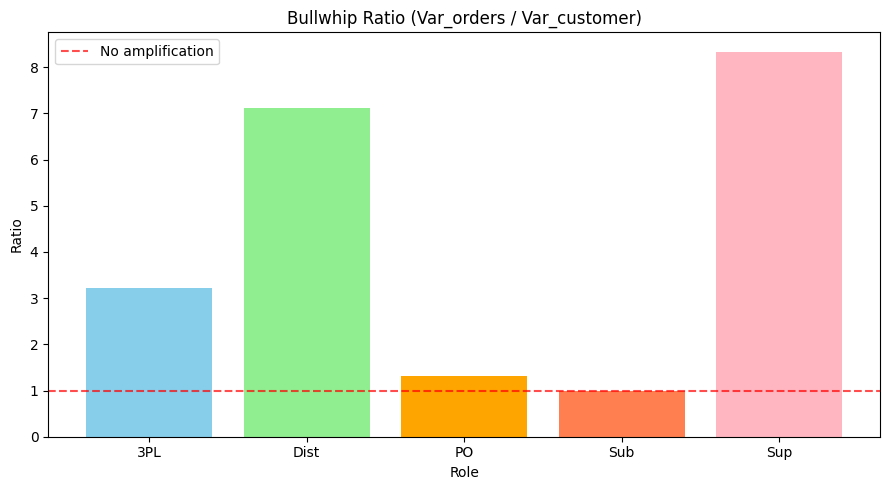

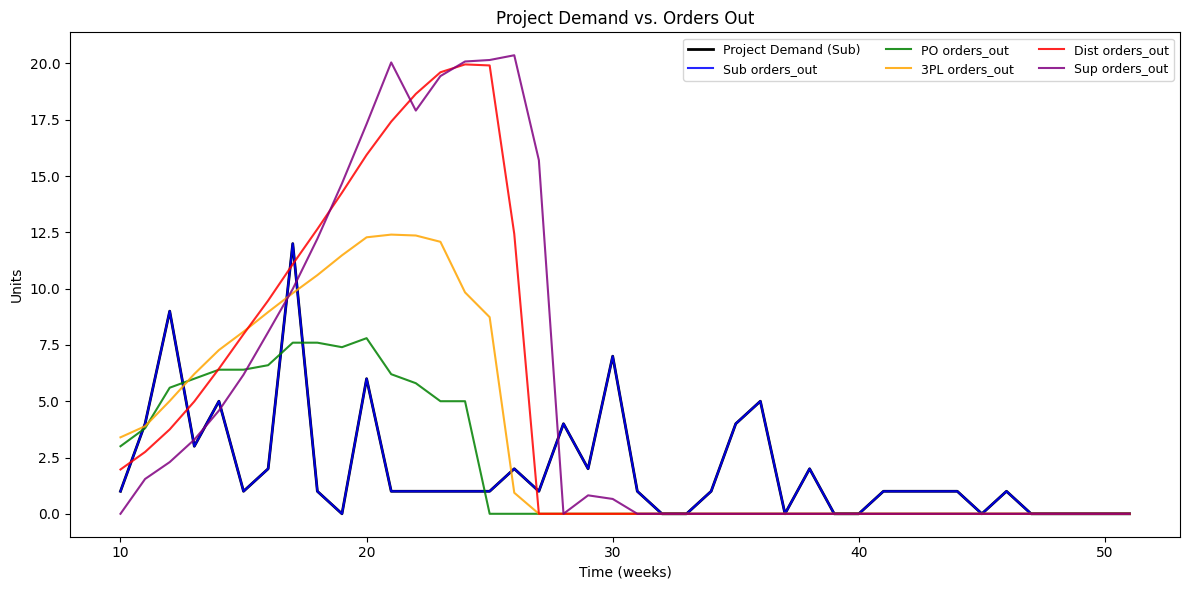

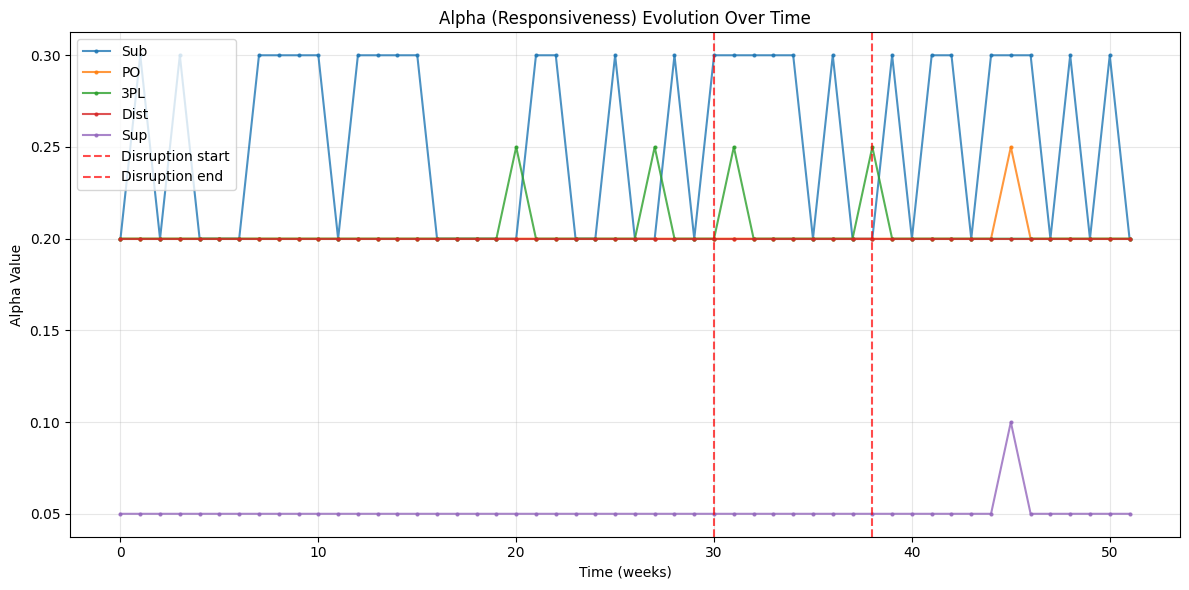

In [7]:
# ===== R5 — KPIs + coefficient & sharing summaries =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define burn-in period to exclude initial startup effects
burnIn = 10  # exclude first 10 weeks from analysis

roles_holding = [r for r in ROLES if r != "GC"]

def compute_metrics_roles(hist, demand, roles, burnIn=0):
   rows = []
   cust = np.asarray(demand[burnIn:], dtype=float)
   var_cust = float(np.var(cust, ddof=0))
   std_cust = float(np.std(cust, ddof=0))
   mean_cust = float(np.mean(cust))

   for r in roles:
       orders = np.asarray(hist["orders_out"][r][burnIn:], dtype=float)
       var_orders = float(np.var(orders, ddof=0))
       std_orders = float(np.std(orders, ddof=0))
       mean_orders = float(np.mean(orders))

       rows.append({
           "role": r,
           "bullwhip_ratio_var": (var_orders / var_cust) if var_cust > 0 else np.nan,
           "amplification_std": (std_orders / std_cust) if std_cust > 0 else np.nan,
           "mean_ratio": (mean_orders / mean_cust) if mean_cust > 0 else np.nan,
       })
   return pd.DataFrame(rows).sort_values("role")

# ---- KPIs
df_kpi = compute_metrics_roles(hist_roles, customerDemand, roles_holding, burnIn=burnIn)
print(f"Bullwhip metrics (post burn-in = {burnIn}):")
print(df_kpi.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# ---- Coefficient logs
rows = []
for r, logs in coeff_logs.items():
   for rec in logs:
       rows.append({"role": r, **{k: rec.get(k) for k in ("t","alpha","service_level","lot_multiplier","expedite")}})
coeff_df = pd.DataFrame(rows).sort_values(["role","t"])
print("\nSample of coefficient choices:")
print(coeff_df.head(12).to_string(index=False))  # Show more samples for 6 roles

# Distributions by role
alpha_dist = coeff_df.groupby(["role","alpha"]).size().rename("count").reset_index()
sl_dist    = coeff_df.groupby(["role","service_level"]).size().rename("count").reset_index()
lot_dist   = coeff_df.groupby(["role","lot_multiplier"]).size().rename("count").reset_index()
exp_dist   = coeff_df.groupby(["role","expedite"]).size().rename("count").reset_index()

print("\nAlpha choices (counts):")
print(alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int))
print("\nService level choices (counts):")
print(sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int))
print("\nLot multiplier choices (counts):")
print(lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int))
print("\nExpedite choices (counts):")
print(exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int))

# ---- Sharing policy changes summary
policy_rows = []
for r, logs in coeff_logs.items():
   add_total = sum(len(rec.get("share_add", [])) for rec in logs)
   drop_total = sum(len(rec.get("share_drop", [])) for rec in logs)
   policy_rows.append({"role": r, "share_add_total": add_total, "share_drop_total": drop_total})
df_policy = pd.DataFrame(policy_rows).sort_values("role")
print("\nSharing policy changes (totals over run):")
print(df_policy.to_string(index=False))

# Current published keys by role (from InfoBank policies)
current_share = {r: profiles[r].share_keys for r in ROLES}
print("\nCurrent share policy keys by role:")
for r in ROLES:
   print(f"  {r}: {current_share[r]}")

# ---- Enhanced Analysis for 6-role chain
print("\n=== 6-ECHELON CHAIN ANALYSIS ===")

# Role-specific coefficient averages
print("\nAverage coefficients by role:")
role_avg_coeffs = coeff_df.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
print(role_avg_coeffs.round(3))

# Expedite frequency by role
print("\nExpedite frequency by role:")
expedite_freq = coeff_df.groupby("role")["expedite"].mean()
print(expedite_freq.round(3))

# Pre-crisis vs Crisis vs Post-crisis comparison
periods = {
   "pre_crisis": (0, 30),
   "crisis": (30, 38),
   "post_crisis": (38, 52)
}

print("\nPeriod-based coefficient analysis:")
for period_name, (start, end) in periods.items():
   period_data = coeff_df[(coeff_df["t"] >= start) & (coeff_df["t"] < end)]
   if len(period_data) > 0:
       print(f"\n{period_name.upper()}:")
       period_avg = period_data.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
       print(period_avg.round(3))

# ---- Plots
# 1) Bullwhip ratio bar
plt.figure(figsize=(9,5))
plt.bar(df_kpi["role"], df_kpi["bullwhip_ratio_var"], color=['skyblue', 'lightgreen', 'orange', 'coral', 'lightpink'])
plt.axhline(1.0, linestyle="--", color='red', alpha=0.7, label='No amplification')
plt.title("Bullwhip Ratio (Var_orders / Var_customer)")
plt.ylabel("Ratio"); plt.xlabel("Role")
plt.legend(); plt.tight_layout(); plt.show()

# 2) Orders_out vs. customer demand (post burn-in)
t_idx = np.arange(len(customerDemand))
plt.figure(figsize=(12,6))
plt.plot(t_idx[burnIn:], customerDemand[burnIn:], label="Project Demand (Sub)", linewidth=2, color='black')
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, r in enumerate(roles_holding):
   plt.plot(t_idx[burnIn:], hist_roles["orders_out"][r][burnIn:],
            label=f"{r} orders_out", alpha=0.85, color=colors[i])
plt.title("Project Demand vs. Orders Out")
plt.xlabel("Time (weeks)"); plt.ylabel("Units")
plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

# 3) Alpha evolution by role
plt.figure(figsize=(12,6))
for r in roles_holding:
   if r in coeff_logs:
       times = [rec["t"] for rec in coeff_logs[r]]
       alphas = [rec["alpha"] for rec in coeff_logs[r]]
       plt.plot(times, alphas, label=f"{r}", marker='o', markersize=2, alpha=0.8)

plt.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Disruption start')
plt.axvline(x=38, color='red', linestyle='--', alpha=0.7, label='Disruption end')
plt.title("Alpha (Responsiveness) Evolution Over Time")
plt.xlabel("Time (weeks)"); plt.ylabel("Alpha Value")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ---- Optional: save summaries
# coeff_df.to_csv("coeff_choices_6role.csv", index=False)
# df_kpi.to_csv("kpi_bullwhip_6role.csv", index=False)
# df_policy.to_csv("sharing_changes_6role.csv", index=False)

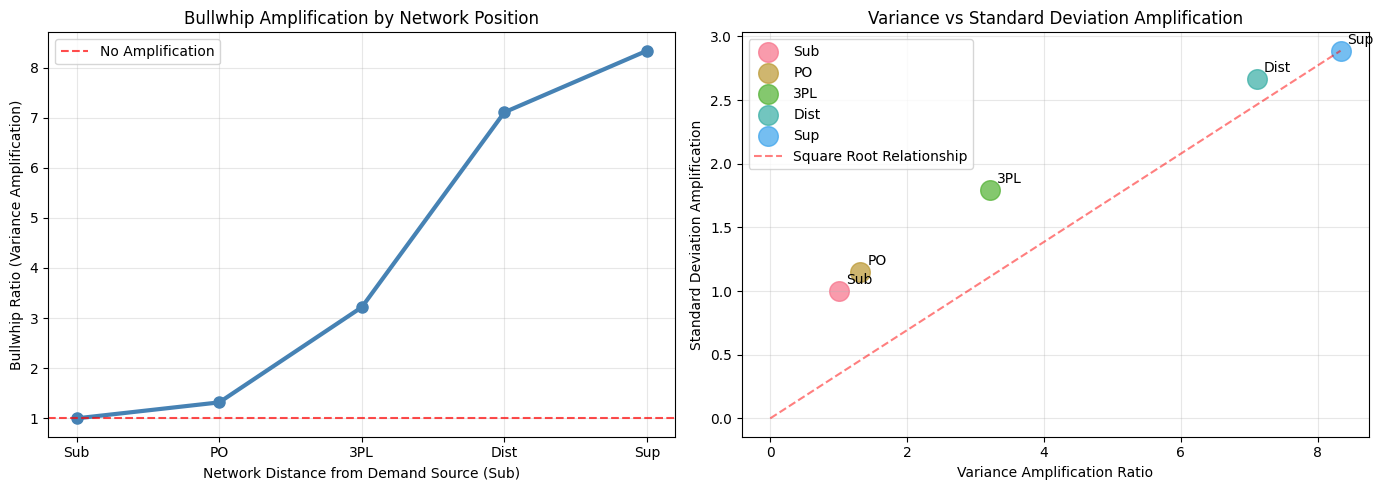

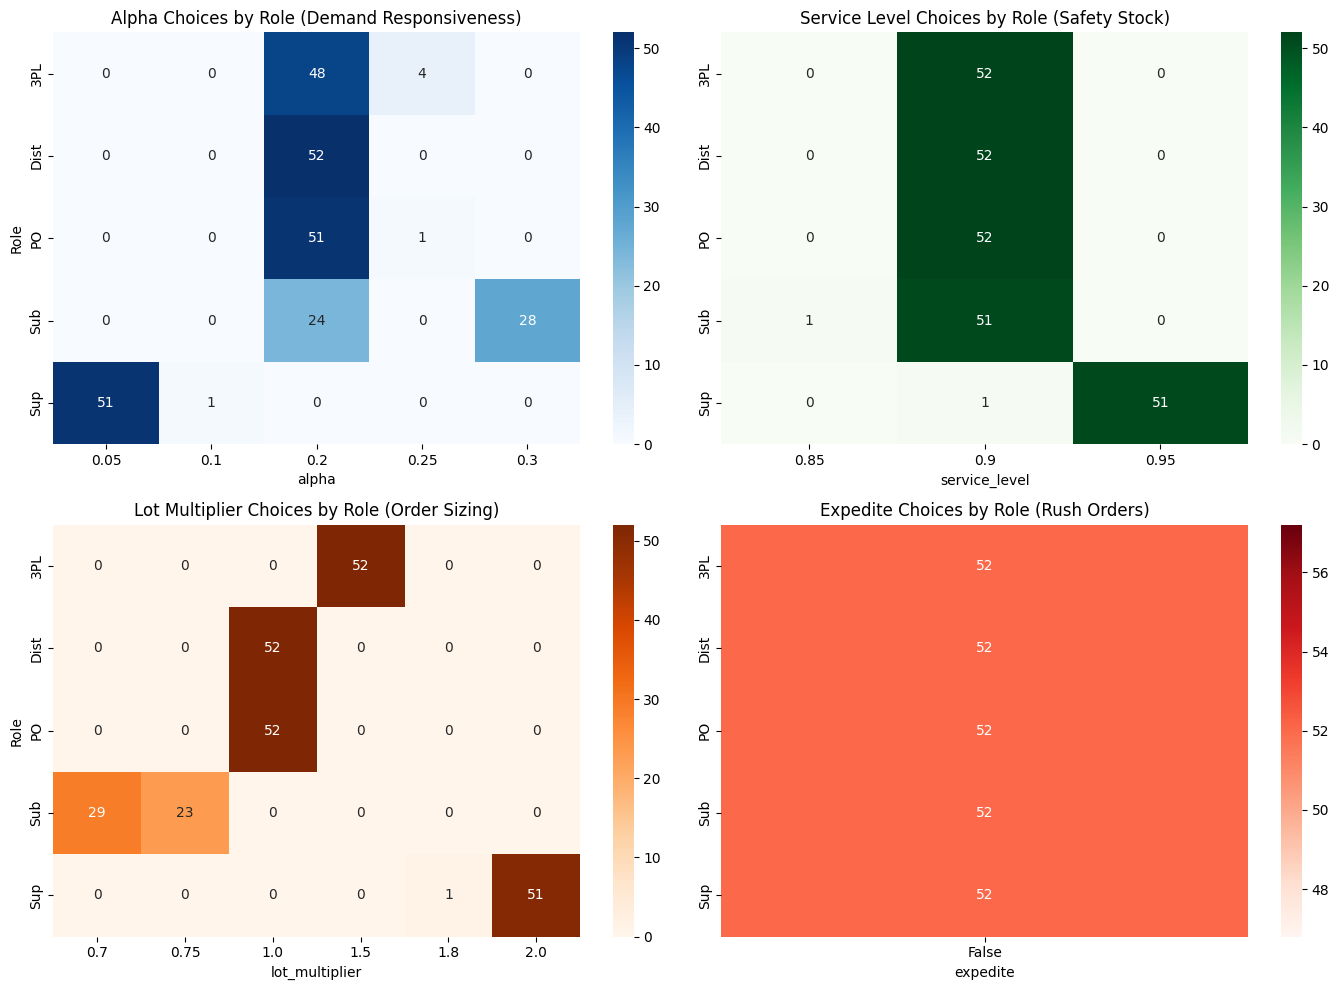

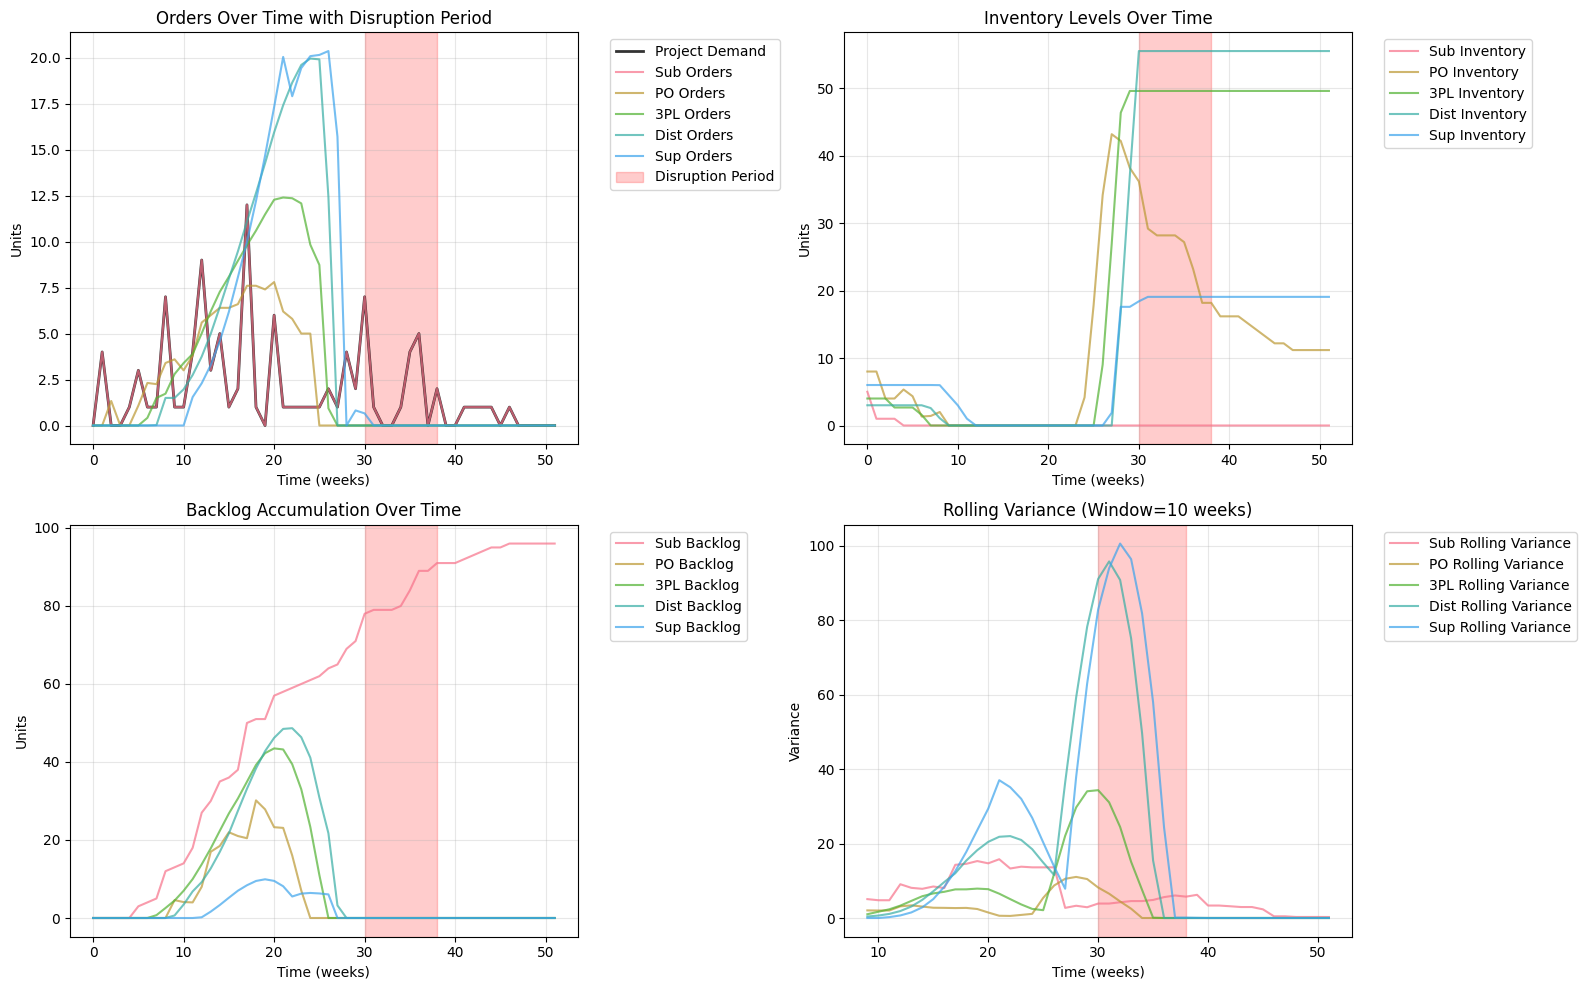

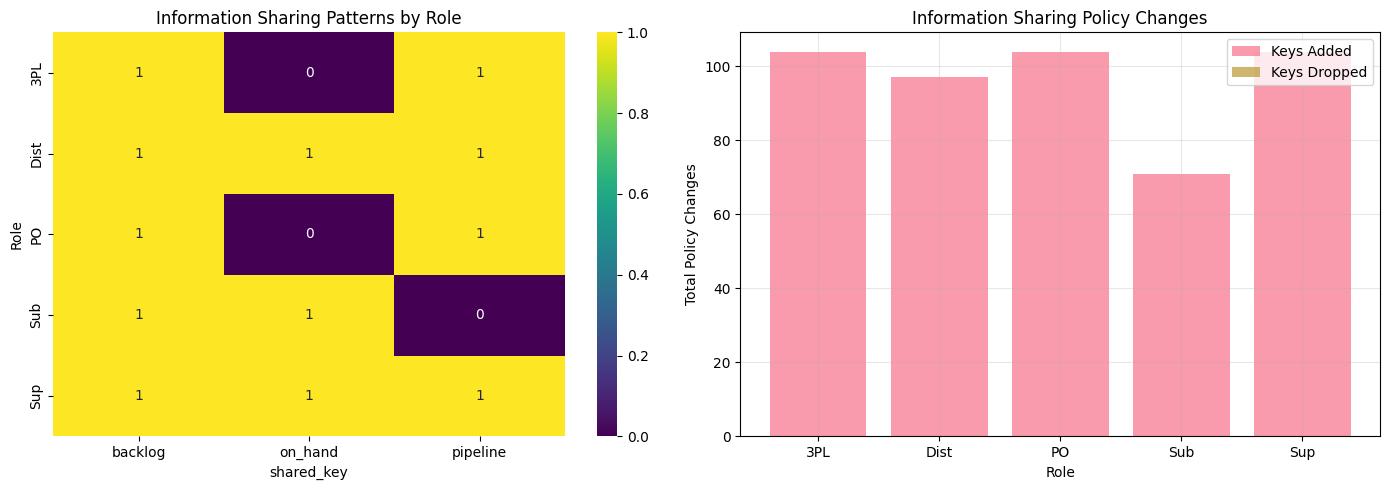

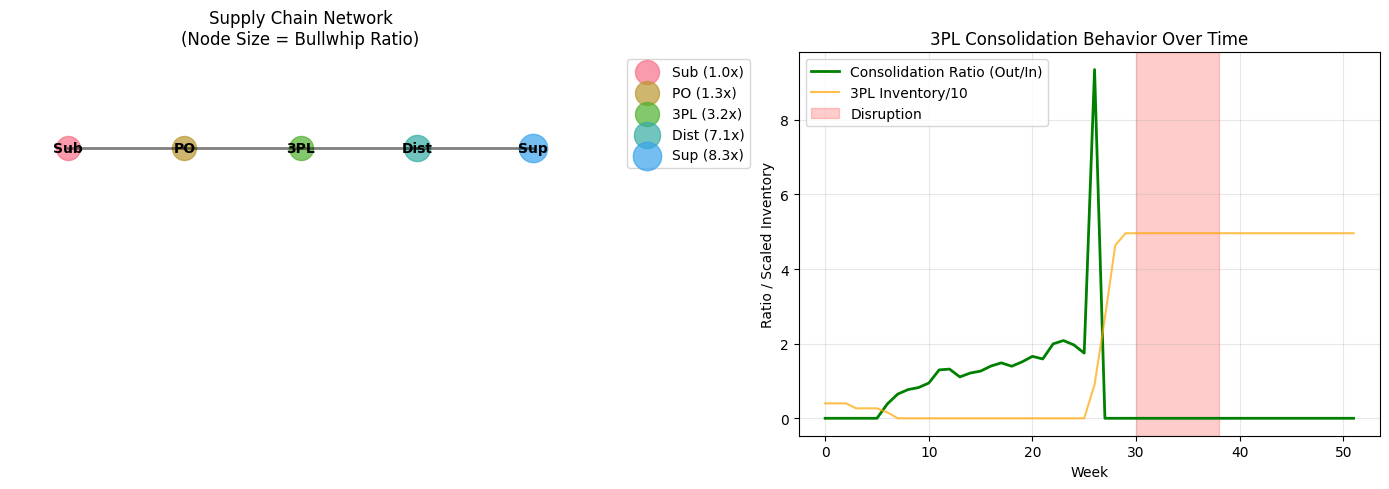

/tmp/ipython-input-666606115.py:220: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([role_alphas[role] for role in roles_ordered], labels=roles_ordered)


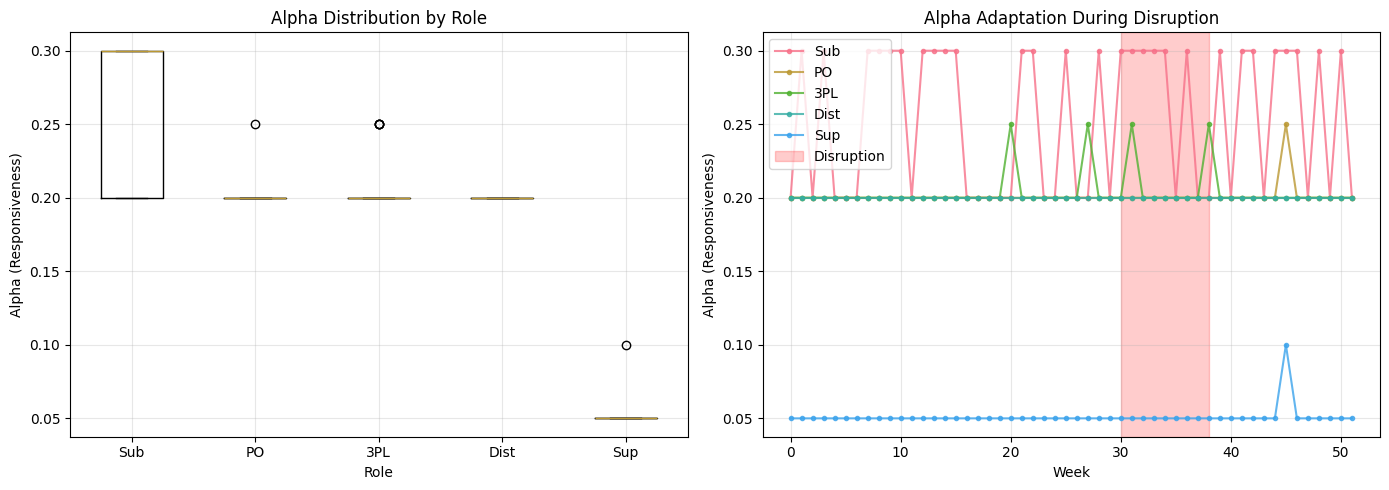

In [8]:
# ===== Comprehensive Visualizations =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

plt.style.use('default')
sns.set_palette("husl")

# 1) BULLWHIP CASCADE ANALYSIS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bullwhip ratios with network distance - updated for 6-role chain
roles_ordered = ["Sub", "PO", "3PL", "Dist", "Sup"]
bullwhip_values = [df_kpi[df_kpi["role"] == r]["bullwhip_ratio_var"].iloc[0] for r in roles_ordered]
network_distances = [0, 1, 2, 3, 4]  # Distance from Sub (demand source)

ax1.plot(network_distances, bullwhip_values, 'o-', linewidth=3, markersize=8, color='steelblue')
ax1.set_xlabel('Network Distance from Demand Source (Sub)')
ax1.set_ylabel('Bullwhip Ratio (Variance Amplification)')
ax1.set_title('Bullwhip Amplification by Network Position')
ax1.set_xticks(network_distances)
ax1.set_xticklabels(roles_ordered)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Amplification')
ax1.legend()

# Mean vs Standard Deviation scatter
for i, role in enumerate(roles_ordered):
   row = df_kpi[df_kpi["role"] == role].iloc[0]
   ax2.scatter(row["bullwhip_ratio_var"], row["amplification_std"],
              s=200, alpha=0.7, label=role)
   ax2.annotate(role, (row["bullwhip_ratio_var"], row["amplification_std"]),
               xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('Variance Amplification Ratio')
ax2.set_ylabel('Standard Deviation Amplification')
ax2.set_title('Variance vs Standard Deviation Amplification')
ax2.grid(True, alpha=0.3)
ax2.plot([0, max(bullwhip_values)], [0, max(bullwhip_values)**0.5], 'r--', alpha=0.5, label='Square Root Relationship')
ax2.legend()

plt.tight_layout()
plt.show()

# 2) COEFFICIENT CHOICE HEATMAP BY ROLE
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Alpha choices
alpha_pivot = alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int)
sns.heatmap(alpha_pivot, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Alpha Choices by Role (Demand Responsiveness)')
ax1.set_ylabel('Role')

# Service level choices
sl_pivot = sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int)
sns.heatmap(sl_pivot, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Service Level Choices by Role (Safety Stock)')
ax2.set_ylabel('')

# Lot multiplier choices
lot_pivot = lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int)
sns.heatmap(lot_pivot, annot=True, fmt='d', cmap='Oranges', ax=ax3)
ax3.set_title('Lot Multiplier Choices by Role (Order Sizing)')
ax3.set_ylabel('Role')

# Expedite choices
exp_pivot = exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int)
sns.heatmap(exp_pivot, annot=True, fmt='d', cmap='Reds', ax=ax4)
ax4.set_title('Expedite Choices by Role (Rush Orders)')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# 3) TIME SERIES DECOMPOSITION WITH DISRUPTION
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

t_idx = np.arange(len(customerDemand))
disruption_start = 30  # Week when disruption hits
disruption_end = 38    # Duration of 8 weeks

# Orders over time with disruption marker
ax1.plot(t_idx, customerDemand, 'k-', linewidth=2, label='Project Demand', alpha=0.8)
for role in ["Sub", "PO", "3PL", "Dist", "Sup"]:
   ax1.plot(t_idx, hist_roles["orders_out"][role], label=f'{role} Orders', alpha=0.7)
ax1.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption Period')
ax1.set_title('Orders Over Time with Disruption Period')
ax1.set_xlabel('Time (weeks)')
ax1.set_ylabel('Units')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Inventory levels over time
for role in ["Sub", "PO", "3PL", "Dist", "Sup"]:
   ax2.plot(t_idx, hist_roles["on_hand"][role], label=f'{role} Inventory', alpha=0.7)
ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax2.set_title('Inventory Levels Over Time')
ax2.set_xlabel('Time (weeks)')
ax2.set_ylabel('Units')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# Backlog accumulation
for role in ["Sub", "PO", "3PL", "Dist", "Sup"]:
   ax3.plot(t_idx, hist_roles["backlog"][role], label=f'{role} Backlog', alpha=0.7)
ax3.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax3.set_title('Backlog Accumulation Over Time')
ax3.set_xlabel('Time (weeks)')
ax3.set_ylabel('Units')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

# Rolling variance (bullwhip over time)
window = 10
for role in ["Sub", "PO", "3PL", "Dist", "Sup"]:
   rolling_var = pd.Series(hist_roles["orders_out"][role]).rolling(window).var()
   ax4.plot(t_idx, rolling_var, label=f'{role} Rolling Variance', alpha=0.7)
ax4.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax4.set_title(f'Rolling Variance (Window={window} weeks)')
ax4.set_xlabel('Time (weeks)')
ax4.set_ylabel('Variance')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4) INFORMATION SHARING ANALYSIS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Current sharing policy by role
sharing_data = []
for role in ROLES:
   for key in current_share[role]:
       sharing_data.append({"role": role, "shared_key": key})
sharing_df = pd.DataFrame(sharing_data)

if not sharing_df.empty:
   sharing_counts = sharing_df.groupby(["role", "shared_key"]).size().reset_index(name="count")
   sharing_pivot = sharing_counts.pivot(index="role", columns="shared_key", values="count").fillna(0).astype(int)
   sns.heatmap(sharing_pivot, annot=True, fmt='d', cmap='viridis', ax=ax1)
ax1.set_title('Information Sharing Patterns by Role')
ax1.set_ylabel('Role')

# Sharing policy changes over time
ax2.bar(df_policy["role"], df_policy["share_add_total"], alpha=0.7, label='Keys Added')
ax2.bar(df_policy["role"], df_policy["share_drop_total"], alpha=0.7, label='Keys Dropped')
ax2.set_title('Information Sharing Policy Changes')
ax2.set_xlabel('Role')
ax2.set_ylabel('Total Policy Changes')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5) NETWORK STRUCTURE VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Position nodes for network
positions = {"Sub": (0, 1), "PO": (1, 1), "3PL": (2, 1), "Dist": (3, 1), "Sup": (4, 1)}
bullwhip_dict = dict(zip(roles_ordered, bullwhip_values))
bullwhip_dict["GC"] = 1.0

# Draw network
for role, (x, y) in positions.items():
   if role in bullwhip_dict:
       size = max(300, bullwhip_dict[role] * 50)  # Scale node size by bullwhip
       ax1.scatter(x, y, s=size, alpha=0.7, label=f'{role} ({bullwhip_dict[role]:.1f}x)')
       ax1.annotate(role, (x, y), ha='center', va='center', fontweight='bold')

# Draw connections for 6-role chain
connections = [("Sub", "PO"), ("PO", "3PL"), ("3PL", "Dist"), ("Dist", "Sup")]
for start, end in connections:
   x1, y1 = positions[start]
   x2, y2 = positions[end]
   ax1.plot([x1, x2], [y1, y2], 'k-', alpha=0.5, linewidth=2)

ax1.set_title('Supply Chain Network\n(Node Size = Bullwhip Ratio)')
ax1.set_xlim(-0.5, 4.5)
ax1.set_ylim(-0.5, 1.5)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.axis('off')

# 3PL Consolidation Analysis
consolidation_data = []
for t in range(len(customerDemand)):
   consolidation_data.append({
       "week": t,
       "3PL_in": hist_roles["orders_in"]["3PL"][t],
       "3PL_out": hist_roles["orders_out"]["3PL"][t],
       "3PL_inventory": hist_roles["on_hand"]["3PL"][t],
       "consolidation_ratio": hist_roles["orders_out"]["3PL"][t] / max(hist_roles["orders_in"]["3PL"][t], 0.1)
   })

consol_df = pd.DataFrame(consolidation_data)
ax2.plot(consol_df["week"], consol_df["consolidation_ratio"], 'g-', linewidth=2, label='Consolidation Ratio (Out/In)')
ax2.plot(consol_df["week"], consol_df["3PL_inventory"]/10, 'orange', alpha=0.7, label='3PL Inventory/10')
ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
ax2.set_title('3PL Consolidation Behavior Over Time')
ax2.set_xlabel('Week')
ax2.set_ylabel('Ratio / Scaled Inventory')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6) NEW: ROLE-SPECIFIC ALPHA STRATEGIES
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Alpha distribution by role
role_alphas = {}
for role in roles_ordered:
   if role in coeff_logs:
       role_alphas[role] = [c["alpha"] for c in coeff_logs[role]]

ax1.boxplot([role_alphas[role] for role in roles_ordered], labels=roles_ordered)
ax1.set_title('Alpha Distribution by Role')
ax1.set_ylabel('Alpha (Responsiveness)')
ax1.set_xlabel('Role')
ax1.grid(True, alpha=0.3)

# Alpha evolution during disruption
for role in roles_ordered:
   if role in coeff_logs:
       times = [c["t"] for c in coeff_logs[role]]
       alphas = [c["alpha"] for c in coeff_logs[role]]
       ax2.plot(times, alphas, 'o-', label=role, alpha=0.8, markersize=3)

ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
ax2.set_title('Alpha Adaptation During Disruption')
ax2.set_xlabel('Week')
ax2.set_ylabel('Alpha (Responsiveness)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()